# Dense SHD comparison: LIF, PIF, and heterogeneous PIF

PIF is a lightweight alternative to LIF. It removes the leaky membrane and synaptic states and uses a periodic reset to keep the membrane bounded. Because this changes the membrane dynamics, PIF also needs its own initializer.

This notebook checks four things:

1. how PIF membrane dynamics respond to Poisson input;
2. whether PIF and heterogeneous PIF reach useful SHD accuracy;
3. whether they use fewer EFLOPs than LIF;
4. whether the hidden neurons avoid zero-rate and every-step spiking behavior.

All three classifiers use dense weights and one seed. EFLOPs include the readout. The default run is 50 epochs; set `PIF_EPOCHS=500` for the longer historical run.

## 1. Environment

The next cell locates the repository and installs only missing runtime dependencies. `randman` is installed from its official repository because Stork imports it but it is not published on PyPI.

The default device policy is backend-agnostic: CUDA is selected first when available, then Apple MPS, then CPU. Set `PIF_DEVICE=mps`, `PIF_DEVICE=cpu`, or for example `PIF_DEVICE=cuda:0` to override it. Training defaults to 50 epochs and can be overridden with `PIF_EPOCHS`. Set `PIF_NOTEBOOK_SMOKE=1` before starting the kernel for a structural smoke run.

In [1]:
from pathlib import Path
import importlib.util
import os
import random
import subprocess
import sys


def find_repo_root(start=Path.cwd()):
    for candidate in (start, *start.parents):
        if (candidate / "stork" / "periodic_reset").is_dir():
            return candidate
    raise RuntimeError(
        "Could not find the repository root. Start Jupyter inside this repository."
    )


REPO_ROOT = find_repo_root()
sys.path.insert(0, str(REPO_ROOT))

missing = []
if importlib.util.find_spec("h5py") is None:
    missing.append("h5py")
if importlib.util.find_spec("pandas") is None:
    missing.append("pandas")
if importlib.util.find_spec("randman") is None:
    missing.append("git+https://github.com/fzenke/randman.git")
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

print("Repository located.")

Repository located.


In [2]:
import gzip
import hashlib
import shutil
import urllib.request
from collections import OrderedDict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

import stork
from stork.connections import Connection
from stork.datasets import DatasetView, HDF5Dataset
from stork.generators import StandardGenerator
from stork.initializers import (
    DistInitializer,
    FluctuationDrivenCenteredNormalInitializer,
)
from stork.loss_stacks import MaxOverTimeCrossEntropy
from stork.models import RecurrentSpikingModel
from stork.nodes import InputGroup, LIFGroup, ReadoutGroup
from stork.optimizers import SMORMS3
from stork.periodic_reset import (
    EffectiveFlopsCounter,
    HeterogeneousPIFGroup,
    NonLeakyReadoutGroup,
    PIFGroup,
    PeriodicResetFluctuationDrivenInitializer,
)


SEED = 42
DT = 2e-3
N_STEPS = 349                  # explicit: do not recompute from floating-point division
DURATION = 0.7
N_INPUTS = 700
N_CLASSES = 20
N_HIDDEN_LAYERS = 3
N_HIDDEN_UNITS = 128
BATCH_SIZE = 400
REFERENCE_EPOCHS = 500
EPOCHS = int(os.environ.get("PIF_EPOCHS", "50"))
LEARNING_RATE = 5e-3
NU = 15.8
TARGET_MEAN = 0.0
TARGET_STD = 1.0

LIF_TAU_MEM = 20e-3
LIF_TAU_SYN = 10e-3
PIF_TAU = 40e-3
HETERO_CONCENTRATION = 2.0
READOUT_TAU_MEM = 0.7
READOUT_INITIAL_STATE = -1e-3

SMOKE_TEST = os.environ.get("PIF_NOTEBOOK_SMOKE", "0") == "1"
RUN_EPOCHS = 1 if SMOKE_TEST else EPOCHS
RUN_HIDDEN_LAYERS = 1 if SMOKE_TEST else N_HIDDEN_LAYERS
RUN_HIDDEN_UNITS = 16 if SMOKE_TEST else N_HIDDEN_UNITS
RUN_BATCH_SIZE = 8 if SMOKE_TEST else BATCH_SIZE

def select_device(requested=None):
    '''Resolve an explicit backend or choose the best available accelerator.'''
    requested = (requested or os.environ.get("PIF_DEVICE", "auto")).lower()
    if requested != "auto":
        device = torch.device(requested)
        if device.type == "cuda" and not torch.cuda.is_available():
            raise RuntimeError(f"Requested {requested}, but CUDA is unavailable")
        if device.type == "mps" and not torch.backends.mps.is_available():
            raise RuntimeError("Requested MPS, but torch.backends.mps.is_available() is false")
        return device
    if torch.cuda.is_available():
        return torch.device("cuda:0")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


DEVICE = select_device()
# HDF5-backed datasets and spawned workers are a fragile combination on macOS.
# CUDA runs retain the historical four workers; MPS and CPU stay portable.
N_WORKERS = 4 if DEVICE.type == "cuda" and not SMOKE_TEST else 0
MODEL_LABELS = OrderedDict(
    lif="LIF",
    pif="PIF",
    hetero_pif="heterogeneous PIF",
)
MODEL_COLORS = {
    "lif": "tab:blue",
    "pif": "tab:orange",
    "hetero_pif": "tab:green",
}


def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed()
print(f"Device: {DEVICE}")
print(f"Smoke mode: {SMOKE_TEST}")
print(f"Training epochs: {RUN_EPOCHS}")
if DEVICE.type == "cpu" and not SMOKE_TEST:
    print(f"Warning: CPU is supported, but 3 x {RUN_EPOCHS} epochs will be slow.")

Device: cpu
Smoke mode: False
Training epochs: 50


## 2. SHD download and deterministic split

The files come from the [official Zenke Lab SHD distribution](https://zenkelab.org/resources/spiking-heidelberg-datasets-shd/). Downloads are streamed, checked against the official compressed-file MD5 sums, and decompressed into `data/datasets/hdspikes`. Existing decompressed files are reused.

The historical experiment used a random 90/10 training/validation split with no held-out speaker. The split below is performed once with seed 42 and shared by all three models.

In [3]:
DATA_DIR = REPO_ROOT / "data" / "datasets" / "hdspikes"
SHD_FILES = {
    "shd_train.h5": {
        "url": "https://zenkelab.org/datasets/shd_train.h5.gz",
        "md5": "d47c9825dee33347913e8ce0f2be08b0",
    },
    "shd_test.h5": {
        "url": "https://zenkelab.org/datasets/shd_test.h5.gz",
        "md5": "3062a80ec0c5719404d5b02e166543b1",
    },
}


def md5sum(path, chunk_size=2**20):
    digest = hashlib.md5()
    with Path(path).open("rb") as handle:
        for chunk in iter(lambda: handle.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()


def download_shd_file(filename, spec):
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    destination = DATA_DIR / filename
    if destination.exists():
        print(f"Using existing {destination.relative_to(REPO_ROOT)}")
        return destination

    archive = DATA_DIR / f"{filename}.gz"
    partial = DATA_DIR / f"{filename}.gz.part"
    if not archive.exists() or md5sum(archive) != spec["md5"]:
        partial.unlink(missing_ok=True)
        print(f"Downloading {spec['url']}")
        with urllib.request.urlopen(spec["url"]) as response, partial.open("wb") as out:
            shutil.copyfileobj(response, out, length=2**20)
        observed = md5sum(partial)
        if observed != spec["md5"]:
            partial.unlink(missing_ok=True)
            raise RuntimeError(
                f"MD5 mismatch for {filename}: expected {spec['md5']}, got {observed}"
            )
        partial.replace(archive)

    temporary = DATA_DIR / f"{filename}.tmp"
    print(f"Decompressing {archive.name}")
    with gzip.open(archive, "rb") as source, temporary.open("wb") as target:
        shutil.copyfileobj(source, target, length=2**20)
    temporary.replace(destination)
    return destination


dataset_paths = {
    name: download_shd_file(name, spec) for name, spec in SHD_FILES.items()
}
{name: path.relative_to(REPO_ROOT) for name, path in dataset_paths.items()}

Using existing data/datasets/hdspikes/shd_train.h5
Using existing data/datasets/hdspikes/shd_test.h5


{'shd_train.h5': PosixPath('data/datasets/hdspikes/shd_train.h5'),
 'shd_test.h5': PosixPath('data/datasets/hdspikes/shd_test.h5')}

In [4]:
dataset_kwargs = dict(
    nb_steps=N_STEPS,
    nb_units=N_INPUTS,
    time_scale=1.0 / DT,
    unit_scale=1.0,
    preload=True,
    precompute_dense=False,
    unit_permutation=None,
)

full_train_dataset = HDF5Dataset(dataset_paths["shd_train.h5"], **dataset_kwargs)
test_dataset = HDF5Dataset(dataset_paths["shd_test.h5"], **dataset_kwargs)

split_rng = np.random.RandomState(SEED)
indices = np.arange(len(full_train_dataset))
split_rng.shuffle(indices)
split_at = int(0.9 * len(indices))
train_dataset = DatasetView(full_train_dataset, indices[:split_at])
valid_dataset = DatasetView(full_train_dataset, indices[split_at:])

if SMOKE_TEST:
    train_dataset = torch.utils.data.Subset(train_dataset, range(min(32, len(train_dataset))))
    valid_dataset = torch.utils.data.Subset(valid_dataset, range(min(16, len(valid_dataset))))
    test_dataset = torch.utils.data.Subset(test_dataset, range(min(16, len(test_dataset))))

print(
    f"train={len(train_dataset)}, validation={len(valid_dataset)}, "
    f"test={len(test_dataset)}, steps={N_STEPS}"
)

train=7340, validation=816, test=2264, steps=349


## 3. Dense models

All three models use three feed-forward hidden layers of 128 neurons. There are no recurrent connections, regularizers, or pruned weights. Training uses SMORMS3 with learning rate 0.005 and max-over-time cross-entropy.

- LIF uses `tau_mem=20 ms`, `tau_syn=10 ms`, the standard LIF initializer, and a leaky readout.
- PIF uses a shared `tau=40 ms`, the periodic-reset initializer, and a non-leaky readout.
- heterogeneous PIF draws Gamma-distributed periods with mean `40 ms` and concentration `2`.

For PIF, the forward update is

$$
s_{n,j}=\mathbf{1}[u_{n,j}>\theta_j],
\qquad
u_{n+1,j}=(u_{n,j}+I_{n,j})(1-s_{n,j})(1-r_{n,j}).
$$

The reset flag $r_{n,j}$ is one at the neuron's scheduled reset steps. Input on those steps is discarded. Each neuron gets a random reset phase so the resets are spread over time.

In [5]:
def make_hidden_group(kind, shape, store_membrane=False):
    store_sequences = ["mem"] if store_membrane else None
    if kind == "lif":
        return LIFGroup(
            shape=shape,
            tau_mem=LIF_TAU_MEM,
            tau_syn=LIF_TAU_SYN,
            activation=stork.activations.SuperSpike,
            store_sequences=store_sequences,
        )

    common = dict(
        shape=shape,
        tau=PIF_TAU,
        threshold=1.0,
        activation=stork.activations.SuperSpike,
        store_sequences=store_sequences,
    )
    if kind == "pif":
        return PIFGroup(**common)
    if kind == "hetero_pif":
        return HeterogeneousPIFGroup(
            concentration=HETERO_CONCENTRATION,
            **common,
        )
    raise ValueError(f"Unknown model kind: {kind}")


def make_hidden_initializer(kind):
    if kind == "lif":
        return FluctuationDrivenCenteredNormalInitializer(
            sigma_u=TARGET_STD,
            nu=NU,
            timestep=DT,
            alpha=0.9,
        )
    return PeriodicResetFluctuationDrivenInitializer(
        mu_u=TARGET_MEAN,
        sigma_u=TARGET_STD,
        nu=NU,
        tau=PIF_TAU,
        center_weights=True,
    )


def make_generator():
    return StandardGenerator(
        nb_workers=N_WORKERS,
        persistent_workers=N_WORKERS > 0,
    )


def build_training_model(kind):
    set_seed(SEED)
    model = RecurrentSpikingModel(
        batch_size=RUN_BATCH_SIZE,
        nb_time_steps=N_STEPS,
        nb_inputs=N_INPUTS,
        device=DEVICE,
        dtype=torch.float32,
    )
    input_group = model.add_group(InputGroup(N_INPUTS))
    upstream = input_group
    hidden_groups = []
    initializer = make_hidden_initializer(kind)

    for _ in range(RUN_HIDDEN_LAYERS):
        hidden = model.add_group(make_hidden_group(kind, RUN_HIDDEN_UNITS))
        connection = model.add_connection(Connection(upstream, hidden))
        connection.init_parameters(initializer)
        hidden_groups.append(hidden)
        upstream = hidden

    if kind == "lif":
        readout = model.add_group(
            ReadoutGroup(
                shape=N_CLASSES,
                tau_mem=READOUT_TAU_MEM,
                tau_syn=LIF_TAU_SYN,
                initial_state=READOUT_INITIAL_STATE,
            )
        )
    else:
        readout = model.add_group(
            NonLeakyReadoutGroup(
                shape=N_CLASSES,
                tau_mem=READOUT_TAU_MEM,
                initial_state=READOUT_INITIAL_STATE,
            )
        )

    readout_connection = model.add_connection(
        Connection(upstream, readout, flatten_input=True)
    )
    DistInitializer(
        dist=torch.distributions.Normal(0.0, 1.0),
        scaling="1/sqrt(k)",
    ).initialize(readout_connection)

    model.configure(
        input=input_group,
        output=readout,
        loss_stack=MaxOverTimeCrossEntropy(),
        optimizer=SMORMS3,
        optimizer_kwargs=dict(lr=LEARNING_RATE),
        generator=make_generator(),
        time_step=DT,
        wandb=None,
    )
    model.experiment_kind = kind
    model.experiment_hidden_groups = hidden_groups
    model.experiment_readout = readout
    return model


## 4. PIF initialization and membrane dynamics

Fluctuation-driven initialization chooses the synaptic weight distribution from the input rate and the postsynaptic dynamics. In the standard LIF method from [`00_FluctuationDrivenInitialization.ipynb`](00_FluctuationDrivenInitialization.ipynb), the decaying postsynaptic-potential kernel $\epsilon$ enters through its integrals $\bar\epsilon$ and $\hat\epsilon$. For target membrane mean $\mu_u$ and variance $\sigma_u^2$, the corresponding weight moments are

$$
\mu_w=\frac{\mu_u}{N\nu\bar\epsilon},
\qquad
\sigma_w^2=\frac{\sigma_u^2}{N\nu\hat\epsilon}-\mu_w^2.
$$

PIF has no decaying membrane or synaptic kernel: it accumulates input until a spike or scheduled reset. Averaging its conditional mean and variance over a reset window of duration $\tau$ instead gives

$$
\mu_w=\frac{2\mu_u}{N\nu\tau},
\qquad
\sigma_w^2=\frac{2\sigma_u^2}{N\nu\tau}-\mu_w^2.
$$

The periodic-reset initializer also recenters every sampled weight row. For the usual $\mu_u=0$, this makes the row sum exactly zero and prevents a small finite-sample imbalance from accumulating as drift in the non-leaky membrane.

The figures below use identically seeded PIF populations with the **same reset phases and Poisson input**, changing only the initializer. The standard baseline uses the LIF kernel with `tau_mem=20 ms` and `tau_syn=10 ms`, then applies those weights unchanged to PIF; it is an intentionally mismatched comparison, not a recommended PIF initializer. Spikes are drawn at a fixed height, dashed lines mark threshold and zero, black curves are empirical Gaussian fits, and vertical dotted lines mark scheduled resets. Both figures use the same membrane range so their fluctuation scales can be compared directly.

In [6]:
DYNAMICS_DURATION = 0.4
DYNAMICS_STEPS = int(DYNAMICS_DURATION / DT)
DYNAMICS_UNITS = 16 if SMOKE_TEST else 64


def simulate_pif_dynamics(poisson_input, initializer_kind):
    set_seed(SEED)
    model = RecurrentSpikingModel(
        batch_size=1,
        nb_time_steps=DYNAMICS_STEPS,
        nb_inputs=N_INPUTS,
        device=DEVICE,
        dtype=torch.float32,
    )
    input_group = model.add_group(InputGroup(N_INPUTS))
    hidden = model.add_group(
        make_hidden_group("pif", DYNAMICS_UNITS, store_membrane=True)
    )
    connection = model.add_connection(Connection(input_group, hidden))
    if initializer_kind == "periodic_reset":
        connection.init_parameters(make_hidden_initializer("pif"))
    elif initializer_kind == "standard_lif":
        # The standard initializer requires the LIF kernel time constants.
        # Supply them only while its weights are computed for this baseline.
        hidden.tau_mem = LIF_TAU_MEM
        hidden.tau_syn = LIF_TAU_SYN
        connection.init_parameters(make_hidden_initializer("lif"))
        del hidden.tau_mem, hidden.tau_syn
    else:
        raise ValueError(f"Unknown initializer: {initializer_kind}")
    model.configure(
        input=input_group,
        output=hidden,
        loss_stack=MaxOverTimeCrossEntropy(),
        optimizer=SMORMS3,
        optimizer_kwargs=dict(lr=LEARNING_RATE),
        generator=StandardGenerator(nb_workers=0, persistent_workers=False),
        time_step=DT,
    )
    model.eval()
    with torch.no_grad():
        model.forward_pass(poisson_input, cur_batch_size=1)

    return {
        "membrane": hidden.get_state_sequence("mem")[0].cpu().numpy(),
        "spikes": hidden.get_out_sequence()[0].cpu().numpy(),
        "period steps": hidden.period_steps.cpu().numpy(),
        "offsets": hidden.offset.cpu().numpy(),
    }


set_seed(SEED)
poisson_input = (
    torch.rand(1, DYNAMICS_STEPS, N_INPUTS) < NU * DT
).to(torch.float32)
DYNAMICS_INITIALIZERS = OrderedDict(
    periodic_reset="PIF — periodic-reset FDI",
    standard_lif="PIF — standard LIF FDI",
)
dynamics = OrderedDict(
    (kind, simulate_pif_dynamics(poisson_input, kind))
    for kind in DYNAMICS_INITIALIZERS
)

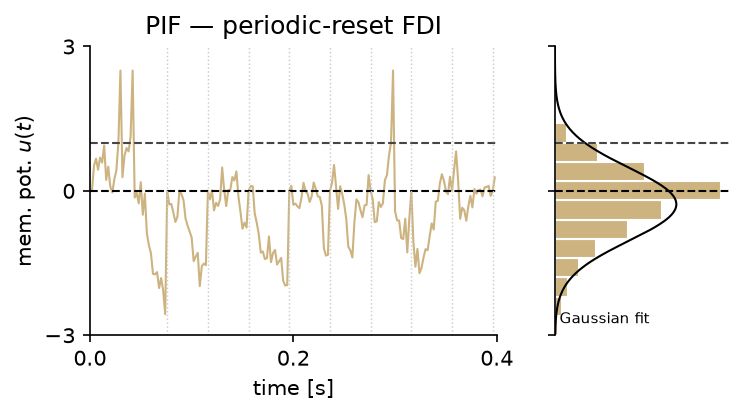

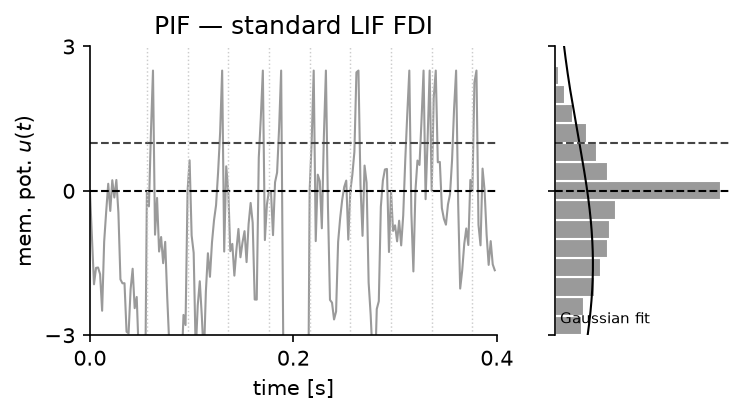

In [7]:
time_axis = np.arange(DYNAMICS_STEPS) * DT
minmax = (-3, 3)
dynamics_colors = {
    "periodic_reset": "#CCB380",
    "standard_lif": "#9A9A9A",
}
color_theta = "#454545"

for initializer_kind, title in DYNAMICS_INITIALIZERS.items():
    result = dynamics[initializer_kind]
    color_membrane = dynamics_colors[initializer_kind]
    membrane = result["membrane"]
    spikes = result["spikes"]
    neuron = int(np.argsort(membrane.std(axis=0))[membrane.shape[1] // 2])
    trace = membrane[:, neuron].copy()
    trace[spikes[:, neuron] != 0] = 2.5
    mu, sigma = membrane.mean(), membrane.std()
    values = np.linspace(*minmax, 300)
    gaussian = np.exp(-0.5 * ((values - mu) / sigma) ** 2) / (
        sigma * np.sqrt(2 * np.pi)
    )

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(5.5, 2.5),
        dpi=150,
        gridspec_kw={"width_ratios": [0.7, 0.3]},
    )

    axes[0].plot(time_axis, trace, color=color_membrane, linewidth=1)
    axes[0].axhline(1.0, color=color_theta, linestyle="--", linewidth=1)
    axes[0].axhline(0.0, color="black", linestyle="--", linewidth=1)
    period = int(result["period steps"][neuron])
    first_reset = int(result["offsets"][neuron] + period)
    for reset_step in range(first_reset, DYNAMICS_STEPS, period):
        axes[0].axvline(
            time_axis[reset_step],
            color="0.8",
            linestyle=":",
            linewidth=0.7,
        )

    axes[1].hist(
        membrane.ravel(),
        bins=15,
        density=True,
        orientation="horizontal",
        color=color_membrane,
        range=minmax,
        edgecolor="white",
    )
    axes[1].plot(gaussian, values, color="black", linewidth=1)
    axes[1].axhline(1.0, color=color_theta, linestyle="--", linewidth=1)
    axes[1].axhline(0.0, color="black", linestyle="--", linewidth=1)

    axes[0].set(
        title=title,
        xlabel="time [s]",
        ylabel=r"mem. pot. $u(t)$",
        xlim=(0, DYNAMICS_DURATION),
        ylim=minmax,
        xticks=[0, DYNAMICS_DURATION / 2, DYNAMICS_DURATION],
        yticks=[minmax[0], 0, minmax[1]],
    )
    axes[1].set_ylim(minmax)
    axes[1].set_yticks([minmax[0], 0, minmax[1]])
    axes[1].set_yticklabels([])
    axes[1].get_xaxis().set_visible(False)
    axes[1].spines["bottom"].set_visible(False)
    axes[1].text(0.02, minmax[0] + 0.25, "Gaussian fit", fontsize=7)

    for axis in axes:
        axis.spines["top"].set_visible(False)
        axis.spines["right"].set_visible(False)
    plt.show()

## 5. Train each dense classifier once

The three models share the dataset split and seed. The seed is reset before model construction and immediately before training so that the run is deterministic and minibatch shuffling starts from the same RNG state. No model selection, pruning, or repeated run is performed. Test loss and accuracy are accumulated with batch-size weighting, so the smaller final batch contributes exactly its number of samples.

The local run uses 50 epochs for each model, which is enough for this behavioral comparison and takes roughly 1 hour 40 minutes on the tested M2. Set `PIF_EPOCHS=500` before starting the kernel only when the historical training length is required.

For each model, the notebook checks `data/periodic_reset/weights`. If its weight file exists, it is loaded and training is skipped. Otherwise the model is trained once and its weights are saved. Saving uses `torch.save` and overwrites the corresponding file. Only model weights are stored—no history, optimizer, metrics, or checkpoint state. The repository already ignores `data/`, so generated weights are never part of the contribution.

In [8]:
WEIGHTS_DIR = REPO_ROOT / "data" / "periodic_reset" / "weights"


def evaluate_sample_weighted(model, dataset):
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    model.eval()
    model.prepare_data(dataset)
    with torch.no_grad():
        for local_x, local_y in model.data_generator(dataset, shuffle=False):
            batch_size = len(local_y)
            output = model.forward_pass(local_x, cur_batch_size=batch_size)
            model.get_total_loss(output, local_y, regularized=False)
            predictions = model.loss_stack.predict(output)
            targets = local_y.to(model.device)
            total_loss += float(model.out_loss.item()) * batch_size
            total_correct += int(predictions.eq(targets).sum().item())
            total_samples += batch_size
    return {
        "loss": total_loss / total_samples,
        "accuracy": total_correct / total_samples,
        "samples": total_samples,
    }


def model_weights_path(kind):
    prefix = "smoke_" if SMOKE_TEST else ""
    return WEIGHTS_DIR / f"{prefix}{kind}.pth"


def save_model_weights(kind, model):
    WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)
    path = model_weights_path(kind)
    state_dict = {
        name: value.detach().cpu()
        for name, value in model.state_dict().items()
    }
    torch.save(state_dict, path)  # Standard overwrite behavior.
    print(f"Saved weights: {path.relative_to(REPO_ROOT)}")


def load_model_weights(kind, model):
    path = model_weights_path(kind)
    if not path.exists():
        return False

    try:
        state_dict = torch.load(path, map_location=DEVICE, weights_only=True)
    except TypeError:  # Compatibility with older PyTorch releases.
        state_dict = torch.load(path, map_location=DEVICE)

    model.load_state_dict(state_dict, strict=True)
    # period_steps and offset are derived, non-persistent buffers. Recompute
    # them after loading tau and phase from PIF weights.
    for hidden in model.experiment_hidden_groups:
        if isinstance(hidden, HeterogeneousPIFGroup):
            hidden.configure(
                model.batch_size,
                model.nb_time_steps,
                model.time_step,
                model.device,
                model.dtype,
            )
    print(f"Loaded weights: {path.relative_to(REPO_ROOT)}")
    return True

In [9]:
models = {}
test_rows = []

for kind, label in MODEL_LABELS.items():
    print(f"\n--- {label} ---")
    model = build_training_model(kind)
    loaded = load_model_weights(kind, model)
    if not loaded:
        print(f"Training {label} for {RUN_EPOCHS} epochs")
        set_seed(SEED)
        model.fit_validate(
            train_dataset,
            valid_dataset,
            nb_epochs=RUN_EPOCHS,
            verbose=True,
        )
        save_model_weights(kind, model)
    else:
        print(f"Skipping training for {label}")

    test_metrics = evaluate_sample_weighted(model, test_dataset)
    models[kind] = model
    test_rows.append(
        {
            "kind": kind,
            "model": label,
            "test loss": test_metrics["loss"],
            "test accuracy": test_metrics["accuracy"],
            "test samples": test_metrics["samples"],
        }
    )
    print(f"{label} test accuracy: {test_metrics['accuracy']:.4f}")

test_results = pd.DataFrame(test_rows)


--- LIF ---
Loaded weights: data/periodic_reset/weights/lif.pth
Skipping training for LIF


LIF test accuracy: 0.7005

--- PIF ---
Loaded weights: data/periodic_reset/weights/pif.pth
Skipping training for PIF


PIF test accuracy: 0.7186

--- heterogeneous PIF ---
Loaded weights: data/periodic_reset/weights/hetero_pif.pth
Skipping training for heterogeneous PIF


heterogeneous PIF test accuracy: 0.7213


## 6. EFLOPs and hidden-neuron activity

The EFLOP count follows the zero-skipping method of [Narduzzi et al. (2025)](https://doi.org/10.1088/2634-4386/addee8). Active binary spikes select weight additions. The counter also includes neuron-state updates, periodic resets, and the readout. PIF resets and the non-leaky readout are extensions used in this notebook.

For LIF layers, synaptic-state activity is not tracked as a separate tensor. The counter assumes that an active membrane implies active synaptic dynamics and uses the membrane-activity mask as a proxy for both. The five-EFLOP active-state factor therefore includes both membrane and synaptic updates. Under this simplified analytical convention, an active membrane costs five EFLOPs, an active membrane receiving an update costs six EFLOPs, an inactive membrane receiving an update costs three EFLOPs after direct-assignment savings, and a fully inactive neuron costs zero EFLOPs.

The same test-set pass records the firing fraction of every hidden neuron and converts it to both firing rate and the exact number of hidden spike events per sample. A **zero-rate neuron** never spikes anywhere in the test set. An **every-step neuron** spikes at every recorded step. These are exact definitions; no arbitrary firing-rate cutoff is used.

The aggregate plot compares all three models. The activity snapshots compare LIF and PIF on the same five test examples; heterogeneous PIF remains in the full-test quantitative comparison. Snapshots are qualitative illustrations, while the reported event counts use the complete test set.

EFLOPs are an analytical count. They are not PyTorch runtime, memory traffic, or measured energy.

In [10]:
def postsynaptic_updating_mask(spikes, weights, epsilon=0.0):
    active_weights = weights.detach().abs() > epsilon
    active_spikes = spikes.detach().ne(0)
    if bool(active_weights.all().item()):
        any_spike = active_spikes.any(dim=-1, keepdim=True)
        return any_spike.expand(*active_spikes.shape[:-1], active_weights.shape[0])
    return torch.matmul(
        active_spikes.to(torch.float32),
        active_weights.T.to(device=spikes.device, dtype=torch.float32),
    ).gt(0)


def count_test_eflops(model, dataset):
    counter = EffectiveFlopsCounter()
    for hidden in model.experiment_hidden_groups:
        if "mem" not in hidden.store_state_sequences:
            hidden.store_state_sequences.append("mem")

    hidden_spike_totals = [
        torch.zeros(int(np.prod(hidden.shape)), dtype=torch.float64)
        for hidden in model.experiment_hidden_groups
    ]
    time_sample_total = 0
    connection_total = 0
    neuron_total = 0
    sample_total = 0
    model.eval()
    model.prepare_data(dataset)

    with torch.no_grad():
        for batch_index, (local_x, local_y) in enumerate(
            model.data_generator(dataset, shuffle=False), start=1
        ):
            model.forward_pass(local_x, cur_batch_size=len(local_y))
            source_groups = [model.input_group, *model.experiment_hidden_groups]
            source_spikes = [group.get_out_sequence() for group in source_groups]

            for layer_index, spikes in enumerate(source_spikes[1:]):
                hidden_spike_totals[layer_index] += (
                    spikes.ne(0)
                    .sum(dim=(0, 1))
                    .reshape(-1)
                    .cpu()
                    .to(torch.float64)
                )
            time_sample_total += len(local_y) * source_spikes[1].shape[1]

            connection_pairs = []
            updating_masks = []
            for spikes, connection in zip(source_spikes, model.connections):
                weights = connection.op.weight
                connection_pairs.append((spikes, weights))
                updating_masks.append(postsynaptic_updating_mask(spikes, weights))

            pif_layers = []
            lif_layers = []
            for hidden, updating in zip(
                model.experiment_hidden_groups, updating_masks[:-1]
            ):
                membrane = hidden.get_state_sequence("mem")
                if isinstance(hidden, HeterogeneousPIFGroup):
                    reset_mask = counter.periodic_reset_mask(
                        hidden.period_steps,
                        hidden.offset,
                        num_steps=N_STEPS,
                        batch_size=len(local_y),
                    )
                    pif_layers.append((membrane, updating, reset_mask))
                else:
                    lif_layers.append((membrane, updating))

            readout_output = model.experiment_readout.get_out_sequence()
            non_leaky_readouts = []
            if isinstance(model.experiment_readout, NonLeakyReadoutGroup):
                non_leaky_readouts.append((readout_output, updating_masks[-1]))
            else:
                lif_layers.append((readout_output, updating_masks[-1]))

            batch_count = counter.count(
                connections=connection_pairs,
                pif_layers=pif_layers,
                lif_layers=lif_layers,
                non_leaky_readouts=non_leaky_readouts,
            )
            connection_total += batch_count.connection_operations
            neuron_total += batch_count.neuron_operations
            sample_total += len(local_y)
            print(
                f"batch {batch_index}: {sample_total}/{len(dataset)} samples",
                end="\r",
            )

    print()
    metrics = {
        "connection EFLOPs/sample": connection_total / sample_total,
        "neuron + readout EFLOPs/sample": neuron_total / sample_total,
        "total EFLOPs/sample": (connection_total + neuron_total) / sample_total,
        "samples counted": sample_total,
    }
    hidden_spike_fractions = [
        totals / time_sample_total for totals in hidden_spike_totals
    ]
    return metrics, hidden_spike_fractions


eflop_rows = []
hidden_activity = {}
for kind, label in MODEL_LABELS.items():
    print(f"Counting {label}")
    row = {"kind": kind, "model": label}
    metrics, hidden_spike_fractions = count_test_eflops(
        models[kind], test_dataset
    )
    row.update(metrics)
    hidden_activity[kind] = hidden_spike_fractions
    eflop_rows.append(row)

eflop_results = pd.DataFrame(eflop_rows)
final_results = test_results.merge(eflop_results, on=["kind", "model"])

activity_rows = []
for kind, layer_fractions in hidden_activity.items():
    for layer_index, fractions in enumerate(layer_fractions, start=1):
        rates_hz = fractions.numpy() / DT
        activity_rows.append(
            {
                "kind": kind,
                "model": MODEL_LABELS[kind],
                "layer": layer_index,
                "spike events/sample": float(fractions.sum().item() * N_STEPS),
                "mean rate (Hz)": rates_hz.mean(),
                "median rate (Hz)": np.median(rates_hz),
                "zero-rate neurons": int((fractions == 0).sum().item()),
                "every-step neurons": int((fractions == 1).sum().item()),
            }
        )

activity_summary = pd.DataFrame(activity_rows)

Counting LIF


batch 6: 2264/2264 samples
Counting PIF


batch 6: 2264/2264 samples
Counting heterogeneous PIF


batch 6: 2264/2264 samples


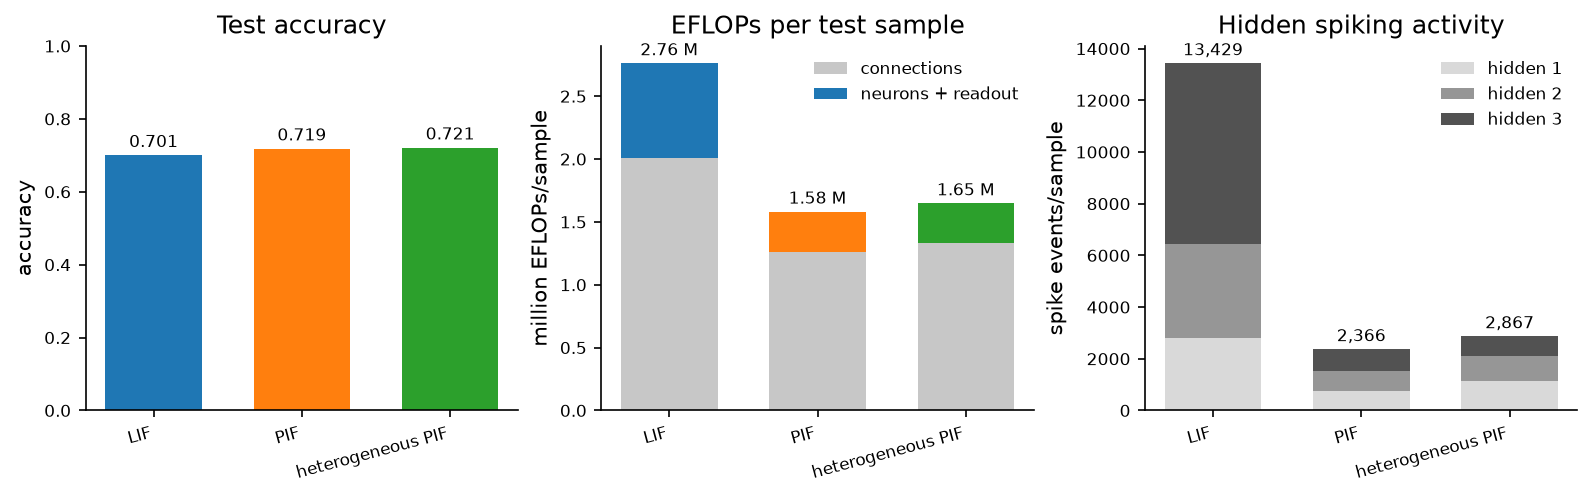

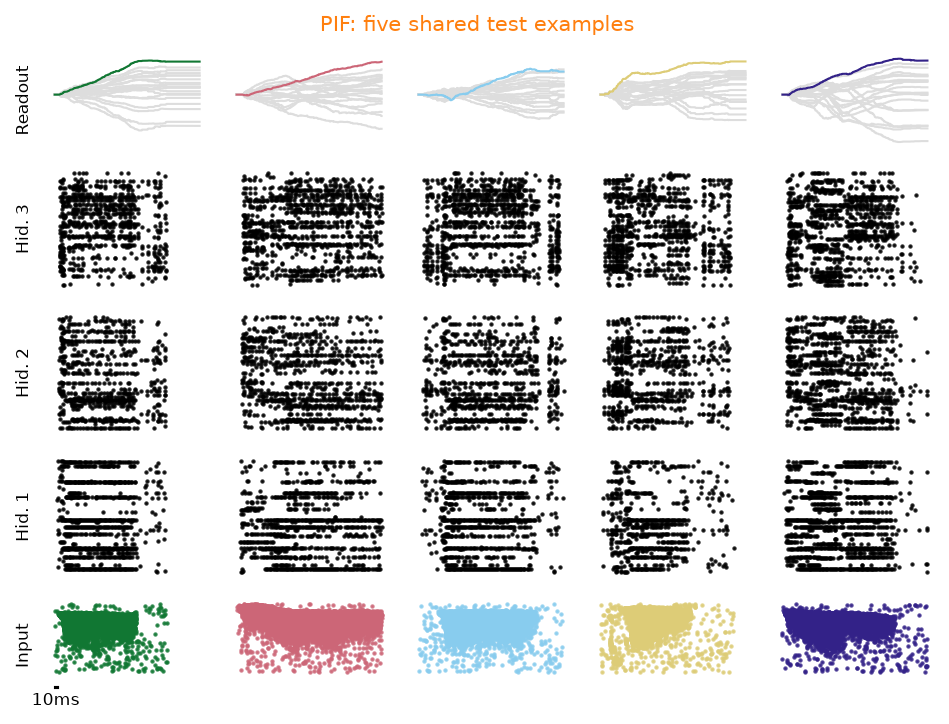

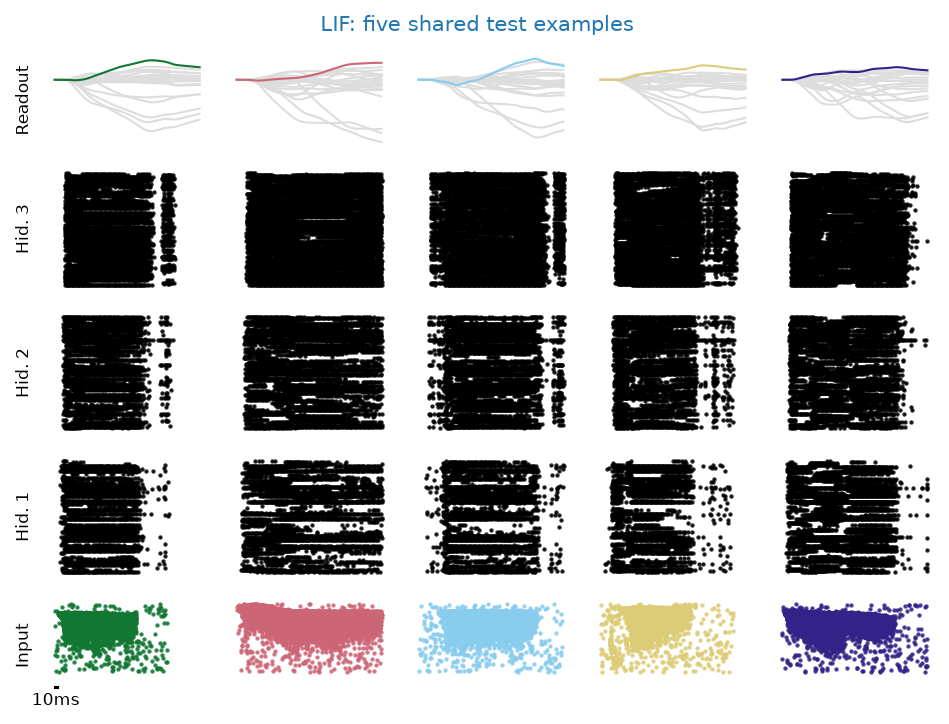

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.2), dpi=150, constrained_layout=True)
x = np.arange(len(final_results))
colors = [MODEL_COLORS[k] for k in final_results["kind"]]

accuracy_bars = axes[0].bar(x, final_results["test accuracy"], color=colors, width=0.65)
axes[0].set(title="Test accuracy", ylabel="accuracy")
axes[0].set_ylim(0, 1)
axes[0].set_xticks(x, final_results["model"], rotation=15, ha="right")
axes[0].bar_label(accuracy_bars, fmt="%.3f", padding=2, fontsize=8)

connection_values = final_results["connection EFLOPs/sample"] / 1e6
neuron_values = final_results["neuron + readout EFLOPs/sample"] / 1e6
axes[1].bar(x, connection_values, label="connections", color="0.78", width=0.65)
total_bars = axes[1].bar(
    x,
    neuron_values,
    bottom=connection_values,
    label="neurons + readout",
    color=colors,
    width=0.65,
)
axes[1].set(title="EFLOPs per test sample", ylabel="million EFLOPs/sample")
axes[1].set_xticks(x, final_results["model"], rotation=15, ha="right")
axes[1].bar_label(
    total_bars,
    labels=[f"{value / 1e6:.2f} M" for value in final_results["total EFLOPs/sample"]],
    padding=2,
    fontsize=8,
)
axes[1].legend(frameon=False, fontsize=8)

spike_bottom = np.zeros(len(final_results))
layer_colors = ["#D9D9D9", "#969696", "#525252"]
for layer_index in range(1, RUN_HIDDEN_LAYERS + 1):
    layer_events = np.array([
        activity_summary.loc[
            (activity_summary["kind"] == kind)
            & (activity_summary["layer"] == layer_index),
            "spike events/sample",
        ].item()
        for kind in final_results["kind"]
    ])
    axes[2].bar(
        x,
        layer_events,
        bottom=spike_bottom,
        width=0.65,
        color=layer_colors[layer_index - 1],
        label=f"hidden {layer_index}",
    )
    spike_bottom += layer_events
axes[2].set(title="Hidden spiking activity", ylabel="spike events/sample")
axes[2].set_xticks(x, final_results["model"], rotation=15, ha="right")
axes[2].bar_label(
    axes[2].containers[-1],
    labels=[f"{value:,.0f}" for value in spike_bottom],
    padding=2,
    fontsize=8,
)
axes[2].legend(frameon=False, fontsize=8)

for axis in axes:
    axis.spines[["top", "right"]].set_visible(False)
    axis.tick_params(labelsize=8)
plt.show()


snapshot_indices = []
snapshot_labels = set()
for sample_index in range(len(test_dataset)):
    _, target = test_dataset[sample_index]
    target = int(target)
    if target in range(5) and target not in snapshot_labels:
        snapshot_indices.append(sample_index)
        snapshot_labels.add(target)
    if len(snapshot_indices) == 5:
        break
snapshot_dataset = torch.utils.data.Subset(test_dataset, snapshot_indices)

for kind in ("pif", "lif"):
    original_group_names = [
        group.name for group in models[kind].experiment_hidden_groups
    ]
    for layer_index, group in enumerate(
        models[kind].experiment_hidden_groups, start=1
    ):
        group.name = f"Hid. {layer_index}"
    figure = plt.figure(figsize=(6.4, 4.8), dpi=150)
    stork.plotting.plot_activity_snapshot(
        models[kind],
        data=snapshot_dataset,
        nb_samples=5,
        point_alpha=0.8,
        show_predictions=False,
    )
    figure.suptitle(
        f"{MODEL_LABELS[kind]}: five shared test examples",
        color=MODEL_COLORS[kind],
        fontsize=10,
        y=0.995,
    )
    figure.subplots_adjust(top=0.94)
    plt.show()
    for group, original_name in zip(
        models[kind].experiment_hidden_groups, original_group_names
    ):
        group.name = original_name